# Preprocesamiento y Modelado

## Limpieza de datos

En el EDA pudimos observar algunas incosistencias como el `RestingBP` = 0 y 172 personas con el `Cholesterol` = 0 lo cual se eliminara e imputara con la mediana respectivamente

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/heart.csv")

# Eliminar RestingBP == 0
df = df[df["RestingBP"] != 0].reset_index(drop=True)

# Imputar Cholesterol == 0 con mediana
mediana_col = df[df["Cholesterol"] != 0]["Cholesterol"].median()
df["Cholesterol"] = df["Cholesterol"].replace(0, mediana_col)

print(f"Filas después de limpieza: {df.shape[0]}")
print(f"Ceros en Cholesterol: {(df['Cholesterol'] == 0).sum()}")

Filas después de limpieza: 917
Ceros en Cholesterol: 0


El dataset quedo con 917 filas y confirmarmos que el colesterol quedo con ceros

## Encoding de variables categoricas

Se pasaran las 5 variables categoricas a numericas

In [16]:
# Encoding de categóricas con OrdinalEncoder
categoricas = df.select_dtypes(include='object').columns.tolist()

encoder = OrdinalEncoder()
df[categoricas] = encoder.fit_transform(df[categoricas])

display(df.head())
display(df.dtypes)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1.0,1.0,140,289,0,1.0,172,0.0,0.0,2.0,0
1,49,0.0,2.0,160,180,0,1.0,156,0.0,1.0,1.0,1
2,37,1.0,1.0,130,283,0,2.0,98,0.0,0.0,2.0,0
3,48,0.0,0.0,138,214,0,1.0,108,1.0,1.5,1.0,1
4,54,1.0,2.0,150,195,0,1.0,122,0.0,0.0,2.0,0


Age                 int64
Sex               float64
ChestPainType     float64
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG        float64
MaxHR               int64
ExerciseAngina    float64
Oldpeak           float64
ST_Slope          float64
HeartDisease        int64
dtype: object

## División train/test 

Se dividen los datos en 80% entrenamiento y un 20% prueba de forma estratificada.

In [17]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (733, 11), Test: (184, 11)


El train nos quedo con 733 filas y 11 columnas mientras que el test nos queduo con 184 filas y 11 columnas

## Función reutilizable

In [ ]:
from sklearn.compose import ColumnTransformer

categoricas = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numericas = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

def train_pipeline(X_train, y_train, model, param_grid):
    preprocessor = ColumnTransformer([
        ('cat', OrdinalEncoder(), categoricas),
        ('num', MinMaxScaler(), numericas)
    ])
    pipe = Pipeline([('prep', preprocessor), ('clf', model)])
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid

En esta funcion reutilizable pasamos las variables categoricas a numericas usando OrdinalEncoder y las variables numericas se escalan con MinMaXSca,er para que todos tengan media 0 y desviación estándar 1

## Entrenamiento de modelos



In [19]:
modelos = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {"clf__n_estimators": [100, 200], "clf__max_depth": [None, 5, 10]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [3, 5, 7, 11]}
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {"clf__n_estimators": [100, 200], "clf__learning_rate": [0.05, 0.1]}
    )
}

grids = {}
resultados = {}
for nombre, (modelo, params) in modelos.items():
    grid = train_pipeline(X_train, y_train, modelo, params)
    auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
    acc = accuracy_score(y_test, grid.predict(X_test))
    resultados[nombre] = {"AUC": round(auc, 3), "Accuracy": round(acc, 3)}
    grids[nombre] = grid
    print(f"{nombre} — AUC: {auc:.3f} | Accuracy: {acc:.3f}")

LogisticRegression — AUC: 0.905 | Accuracy: 0.853
RandomForest — AUC: 0.929 | Accuracy: 0.870
KNN — AUC: 0.917 | Accuracy: 0.870
GradientBoosting — AUC: 0.927 | Accuracy: 0.891


Los cuatro modelos entrenados muestran un rendimiento alto. RandomForest obtuvo el AUC más alto con 0.929, seguido de GradientBoosting con 0.927 y KNN con 0.917. LogisticRegression, siendo el modelo mas sencillo, alcanzó un AUC de 0.905 con una accuracy de 85.3%. GradientBoosting obtuvo la mejor accuracy con 89.1%. Se puede notar que a los modelos no lineales les fue considerablemente mejor que los lineales


## Ranking comparativo

,AUC,Accuracy
RandomForest,0.929,0.870
GradientBoosting,0.927,0.891
KNN,0.917,0.870
LogisticRegression,0.905,0.853


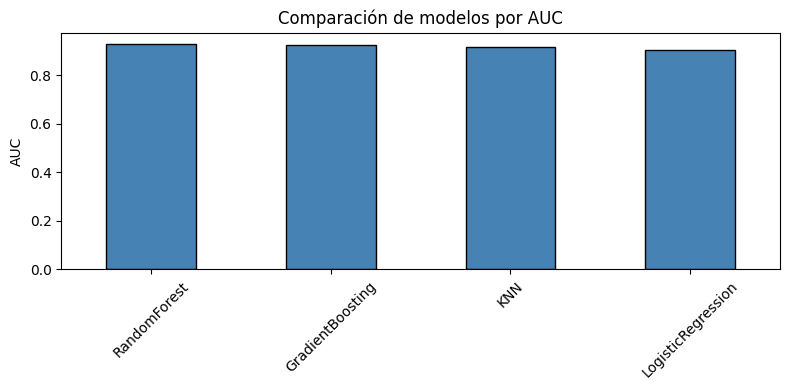

In [20]:
ranking = pd.DataFrame(resultados).T.sort_values("AUC", ascending=False)
display(ranking)

ranking["AUC"].plot(kind="bar", figsize=(8, 4), color="steelblue", edgecolor="black")
plt.title("Comparación de modelos por AUC")
plt.ylabel("AUC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Los 4 modelos tuvieron un buen rendimiento, sin embargo se puede ver que los modelos lineales tuvieron un rendimiento ligeramente mas bajo

## Evaluacion de los modelos

### Matriz de confusion

Las matrices de confusión muestran el desempeño de cada modelo sobre el conjunto de prueba

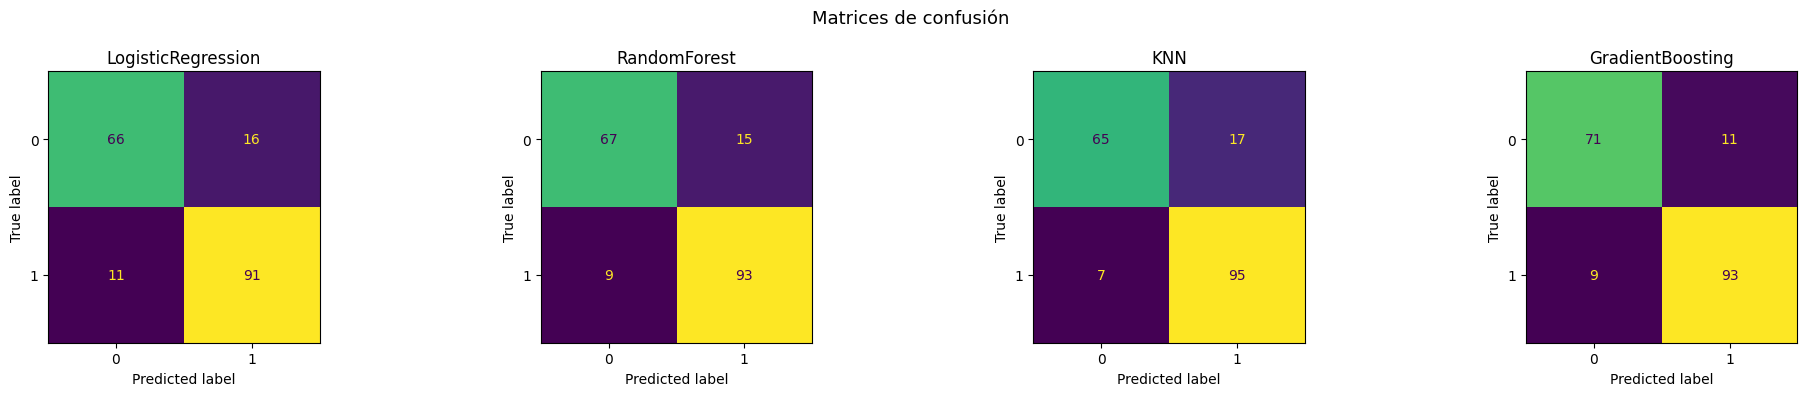

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(resultados), figsize=(20, 4))
for i, (nombre, grid) in enumerate(grids.items()):
    y_pred = grid.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(ax=axes[i], colorbar=False)
    axes[i].set_title(nombre)
plt.suptitle("Matrices de confusión", fontsize=13)
plt.tight_layout()
plt.show()

GradientBoosting es el que mejor clasifica los pacientes sanos (0) con 71 verdaderos negativos y solo 11 falsos positivos. Se puede ver como es KNN es mejor en la clasificación de pacientes enfermos (1) con 95 verdaderos positivos y solo 7 falsos negativos. los falsos negativos son los más críticos predecir que un paciente está sano cuando en realidad tiene enfermedad cardíaca puede tener consecuencias graves.

### Curva ROC

La curva ROC muestra la capacidad de cada modelo para discriminar entre pacientes enfermos y sanos.

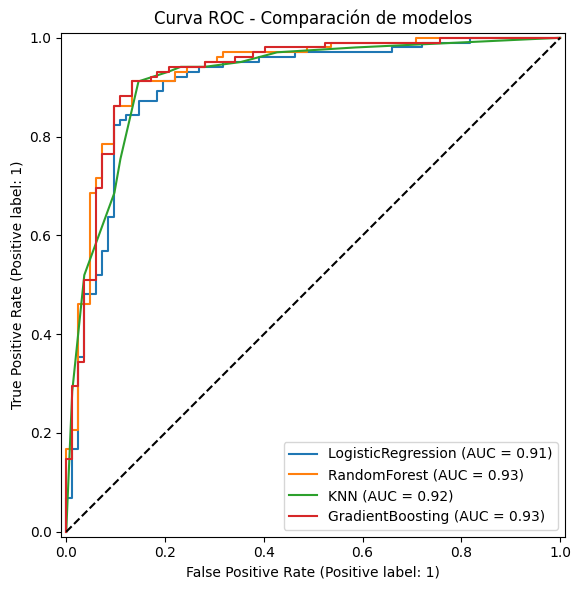

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, grid in grids.items():
    RocCurveDisplay.from_estimator(grid, X_test, y_test, ax=ax, name=nombre)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title("Curva ROC - Comparación de modelos")
plt.tight_layout()
plt.show()

 Todos los modelos se alejan significativamente de la línea diagonal punteada (clasificador aleatorio), lo que indica un buen rendimiento general. RandomForest y GradientBoosting empatan con el AUC más alto de 0.93, seguidos de KNN con 0.92 y LogisticRegression con 0.91. Se elige RandomForest como modelo final por su equilibrio entre AUC, accuracy y menor cantidad de falsos negativos comparado con GradientBoosting.

### Guardado del modelo

In [23]:
import joblib
import os

grid_rf = grids["RandomForest"]

mejor_pipeline_rf = grid_rf.best_estimator_

print("Pipeline a guardar:")
print(mejor_pipeline_rf)
print(f"\nMejores hiperparámetros: {grid_rf.best_params_}")

ruta_modelo = os.path.join("..", "app", "model.joblib")

os.makedirs(os.path.dirname(ruta_modelo), exist_ok=True)

joblib.dump(mejor_pipeline_rf, ruta_modelo)

print(f"¡Modelo guardado exitosamente en '{ruta_modelo}'!")

Pipeline a guardar:
Pipeline(steps=[('scaler', MinMaxScaler()),
                ('clf', RandomForestClassifier(max_depth=5, random_state=42))])

Mejores hiperparámetros: {'clf__max_depth': 5, 'clf__n_estimators': 100}
¡Modelo guardado exitosamente en '../app/model.joblib'!


In [24]:
import os

# Crear carpeta data si no existe (relativa a la ubicación del notebook)
os.makedirs("../data", exist_ok=True)

# Guardar X_train y X_test
X_train.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)

print("✅ Archivos guardados:")
print(f"   - data/X_train.csv ({X_train.shape[0]} filas, {X_train.shape[1]} columnas)")
print(f"   - data/X_test.csv ({X_test.shape[0]} filas, {X_test.shape[1]} columnas)")

✅ Archivos guardados:
   - data/X_train.csv (733 filas, 11 columnas)
   - data/X_test.csv (184 filas, 11 columnas)


### Comparación con SVC (Notebook 1)

El SVC entrenado en el notebook 1 sin fuga obtuvo un AUC de 0.903. A continuación se compara con los modelos entrenados en este notebook.

,AUC,Accuracy
RandomForest,0.931,0.88
GradientBoosting,0.927,0.891
KNN,0.917,0.886
SVC,0.903,-
LogisticRegression,0.891,0.859


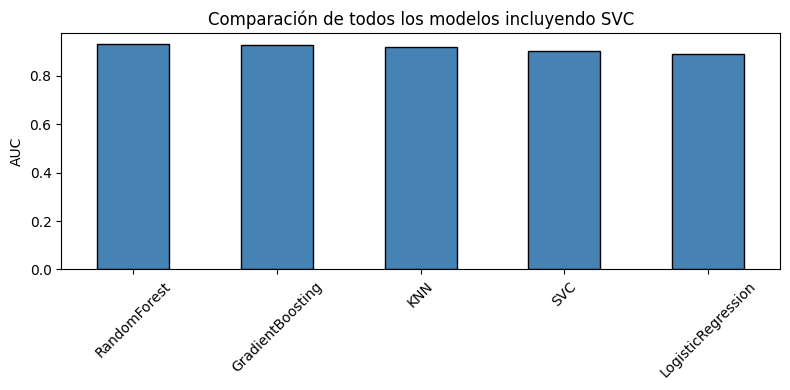

In [22]:
ranking_completo = ranking.copy()
ranking_completo.loc["SVC"] = {"AUC": 0.903, "Accuracy": "-"}
ranking_completo = ranking_completo.sort_values("AUC", ascending=False)
display(ranking_completo)

ranking_completo["AUC"].plot(kind="bar", figsize=(8, 4), color="steelblue", edgecolor="black")
plt.title("Comparación de todos los modelos incluyendo SVC")
plt.ylabel("AUC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se puede observar como RandomForest, GradientBoosting y KNN siguen encabezando la lista, sin embargo, SVC sigue siendo mejor que el modelo lineal